In [1]:
import numpy as np

def generate_time_series(batch_size, n_steps):
    freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)   #  generators data from [0,1)
    time = np.linspace(0, 1, n_steps)
    series = 0.5 * np.sin((time - offsets1) * (freq1 * 10 + 10))  # wave 1
    series += 0.2 * np.sin((time - offsets2) * (freq2 * 20 + 20))  # wave 2
    series += 0.1 * (np.random.rand(batch_size, n_steps) - 0.5)  # noise
    return series[..., np.newaxis].astype(np.float32)
    

In [2]:
# 生成并划分训练、验证、测试集
n_steps = 50
series = generate_time_series(10000, n_steps + 1)

# 训练集：前7000条数据，取前n_steps步作为特征，最后一步作为标签
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
# 验证集：7000-9000条数据，同上划分
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
# 测试集：9000条以后的数据，同上划分
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]

print(np.__version__)

1.26.4


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# # 模拟时间序列数据（匹配原文input_shape=[50,1]）
# np.random.seed(42)
# # 训练集：1000个样本，每个样本是长度50、特征数1的序列
# X_train = np.random.randn(1000, 50, 1).astype(np.float32)
# y_train = np.random.randn(1000, 1).astype(np.float32)
# # 验证集：200个样本，同结构
# X_valid = np.random.randn(200, 50, 1).astype(np.float32)
# y_valid = np.random.randn(200, 1).astype(np.float32)

# 转为PyTorch张量
X_train_tensor = torch.from_numpy(X_train)
y_train_tensor = torch.from_numpy(y_train)
X_valid_tensor = torch.from_numpy(X_valid)
y_valid_tensor = torch.from_numpy(y_valid)
X_test_tensor = torch.from_numpy(X_test)
y_test_tensor = torch.from_numpy(y_test)

In [4]:
X_train_tensor.shape,y_train_tensor.shape

(torch.Size([7000, 50, 1]), torch.Size([7000, 1]))

d:\0002_AI\001_MachineLearning\Hands_On_MachineLearning\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\0002_AI\001_MachineLearning\Hands_On_MachineLearning\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\0002_AI\001_MachineLearning\Hands_On_MachineLearning\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31532 (\N{CJK UNIFIED IDEOGRAPH-7B2C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\0002_AI\001_MachineLearning\Hands_On_MachineLearning\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20010 (\N{CJK UNIFIED IDEOGRAPH-4E2A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\0002_AI\001_M

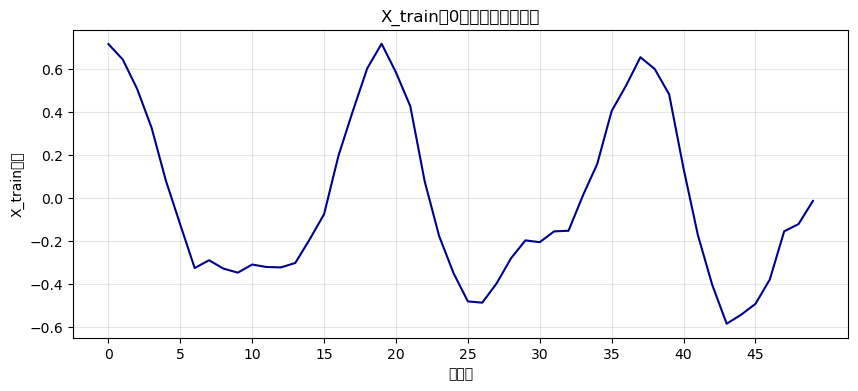

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 提取第0个样本的时序数据：50个时间步，特征维度取0
sample = X_train[0, :, 0]  # 维度：(50,)
time_steps = np.arange(50)  # 生成时间步标签：0,1,...,49

# 绘图
plt.figure(figsize=(10, 4))
plt.plot(time_steps, sample, color='darkblue', linewidth=1.5)
plt.title('X_train第0个样本的时序波形', fontsize=12)
plt.xlabel('时间步', fontsize=10)
plt.ylabel('X_train数值', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(np.arange(0, 50, 5))  # 每5个时间步标注刻度
plt.show()

In [7]:
#Baseline metrics -----Naive forcasting 
# 朴素预测：取序列最后一个值作为预测值
y_pred_naive = X_valid_tensor[:, -1, :]  # 对应原文X_valid[:, -1]
mse_naive = nn.MSELoss()(y_pred_naive, y_valid_tensor).item()
print(f"朴素预测MSE: {mse_naive:.8f}")  # 接近原文的0.020

朴素预测MSE: 0.02022285


In [8]:
#Baseline metrics -----full connected network
# 定义全连接模型（Flatten + Dense）
class FCModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.dense = nn.Linear(50 * 1, 1)  # 50个时间步×1特征

    def forward(self, x):
        x = self.flatten(x)
        return self.dense(x)

# 训练与评估
fc_model = FCModel()
criterion = nn.MSELoss()
optimizer = optim.Adam(fc_model.parameters(), lr=0.001)

# 训练20个epoch
for epoch in range(20):
    fc_model.train()
    optimizer.zero_grad()
    y_pred_fc = fc_model(X_train_tensor)
    loss = criterion(y_pred_fc, y_train_tensor)
    loss.backward()
    optimizer.step()

# 验证集评估
fc_model.eval()
with torch.no_grad():
    y_pred_fc_valid = fc_model(X_valid_tensor)
    mse_fc = criterion(y_pred_fc_valid, y_valid_tensor).item()
print(f"全连接网络MSE: {mse_fc:.8f}")  # 接近原文的0.004

全连接网络MSE: 0.13460417
